In [ ]:
## pip install osmnx geopandas scikit-learn matplotlib folium

In [2]:
import osmnx as ox
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
import osmnx as ox

place = "Knoxville, Tennessee, USA"

area = ox.geocode_to_gdf(place)

tags = {"amenity": True}

gdf = ox.geometries_from_polygon(area.geometry.iloc[0], tags)

In [5]:
gdf = gdf[gdf.geometry.type == "Point"].copy()

In [68]:
gdf = gdf[~gdf["amenity"].isin(["street_lamp", "letter_box"])]

In [69]:
counts = gdf["amenity"].value_counts()

for k, v in counts.items():
    print(k, v)

restaurant 200
place_of_worship 143
fast_food 107
parking_entrance 59
public_bookcase 55
loading_dock 52
bench 42
parking 42
cafe 37
fuel 37
bar 36
school 36
parking_space 25
bank 22
waste_basket 16
dentist 13
clinic 12
drinking_water 12
pharmacy 12
toilets 11
bicycle_parking 11
pub 9
atm 8
post_office 7
waste_disposal 6
veterinary 6
ice_cream 5
grave_yard 5
events_venue 5
car_wash 4
vending_machine 4
charging_station 4
bicycle_repair_station 4
doctors 4
hospital 3
marketplace 3
car_rental 3
animal_shelter 2
weighbridge 2
shelter 2
food_court 2
theatre 2
nursing_home 2
social_facility 2
boat_storage 1
childcare 1
courthouse 1
boat_rental 1
kindergarten 1
fire_station 1
prep_school 1
cinema 1
stripclub 1
fountain 1
device_charging_station 1
post_box 1
university 1
recycling 1
training 1
college 1
library 1
internet_cafe 1


In [70]:
gdf = gdf.to_crs(epsg=3857)

X = np.vstack([
    gdf.geometry.x,
    gdf.geometry.y
]).T

In [71]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=800, min_samples=10)
gdf["dbscan_cluster"] = dbscan.fit_predict(X)

In [72]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
gdf["kmeans_cluster"] = kmeans.fit_predict(X)

C:\Users\bower\AppData\Local\Temp\ipykernel_54412\2860659974.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  db_cmap = cm.get_cmap("tab20", len(db_labels))
C:\Users\bower\AppData\Local\Temp\ipykernel_54412\2860659974.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  km_cmap = cm.get_cmap("tab10", k)


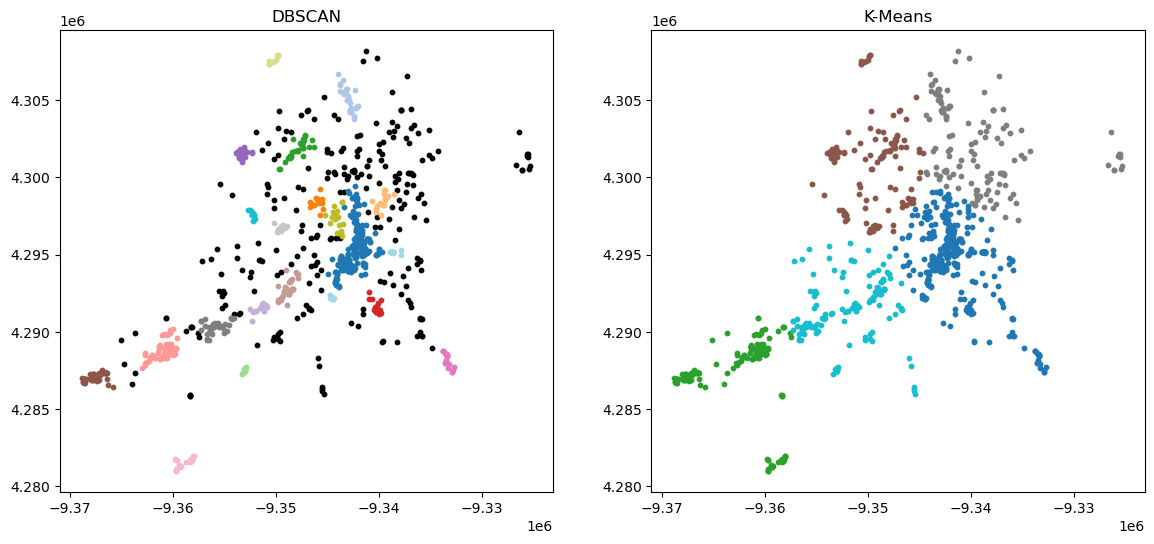

In [73]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================
# DBSCAN (fixed colors)
# =========================
axes[0].set_title("DBSCAN")

db_labels = sorted(gdf["dbscan_cluster"].unique())
db_cmap = cm.get_cmap("tab20", len(db_labels))

db_colors = {
    label: ("black" if label == -1 else mcolors.rgb2hex(db_cmap(i)))
    for i, label in enumerate(db_labels)
}

for c in db_labels:
    subset = gdf[gdf["dbscan_cluster"] == c]
    axes[0].scatter(
        subset.geometry.x,
        subset.geometry.y,
        s=10,
        color=db_colors[c]
    )

# =========================
# KMeans (fixed colors)
# =========================
axes[1].set_title("K-Means")

k = gdf["kmeans_cluster"].nunique()
km_labels = sorted(gdf["kmeans_cluster"].unique())
km_cmap = cm.get_cmap("tab10", k)

km_colors = {
    label: mcolors.rgb2hex(km_cmap(i))
    for i, label in enumerate(km_labels)
}

for c in km_labels:
    subset = gdf[gdf["kmeans_cluster"] == c]
    axes[1].scatter(
        subset.geometry.x,
        subset.geometry.y,
        s=10,
        color=km_colors[c]
    )

plt.show()

In [74]:
gdf["dbscan_cluster"].value_counts()

dbscan_cluster
 0     356
-1     247
 7      80
 10     41
 11     33
 1      32
 4      31
 14     31
 8      31
 13     28
 20     25
 12     21
 16     18
 6      17
 9      16
 3      16
 15     15
 2      14
 5      10
 17     10
 18     10
 19     10
Name: count, dtype: int64

In [75]:
gdf_latlon = gdf.to_crs(epsg=4326)

In [76]:
center = [
    gdf_latlon.geometry.y.mean(),
    gdf_latlon.geometry.x.mean()
]

In [77]:
import folium

m = folium.Map(location=center, zoom_start=12)

In [78]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import folium

# =========================
# FIXED COLOR MAPPING
# =========================
db_labels = sorted(gdf_latlon["dbscan_cluster"].unique())
db_cmap = cm.get_cmap("tab20", len(db_labels))

db_colors = {
    label: ("black" if label == -1 else mcolors.rgb2hex(db_cmap(i)))
    for i, label in enumerate(db_labels)
}

# =========================
# CREATE MAP
# =========================
center = [
    gdf_latlon.geometry.y.mean(),
    gdf_latlon.geometry.x.mean()
]

m = folium.Map(location=center, zoom_start=12)

# =========================
# PLOT POINTS (FIXED COLORS)
# =========================
for c in db_labels:
    subset = gdf_latlon[gdf_latlon["dbscan_cluster"] == c]

    color = db_colors[c]

    for _, row in subset.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=str(row.get("amenity", "unknown"))
        ).add_to(m)


C:\Users\bower\AppData\Local\Temp\ipykernel_54412\3876205151.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  db_cmap = cm.get_cmap("tab20", len(db_labels))


In [79]:
m

In [55]:
len(gdf)

1555